<a href="https://colab.research.google.com/github/KarAnalytics/code_demos/blob/main/GRAPH_RAG_Trade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph RAG: Retrieval-Augmented Generation with Graph Databases

This notebook demonstrates **Graph RAG**, where the knowledge source is a property graph database (using **Kùzu**) rather than a document store or a relational database.

**How it works:**
1. Build a persistent graph database from international trade data (nodes for countries, edges for trade flows).
2. Extract the **graph schema** (node types, relationship types, properties) as context for the LLM.
3. Given a natural-language question, the LLM generates a **Cypher query**.
4. Execute the Cypher query and feed the **structured results** back to the LLM for a natural-language answer.
5. **Visualize** the retrieved subgraph to help students understand exactly what data was retrieved.

**Learning goals:**
- Understand the difference between Graph RAG and DBMS RAG (SQL).
- Learn how property graphs capture relationships that are hard to query in SQL.
- See how Cypher serves as the "retrieval language" for graph-augmented generation.
- Practice grounding LLM answers on multi-hop graph data.

**Provider setup:** Uses llm_cascade github package for using free-tier LLM-platforms.   
Store your LLM API keys in Colab Secrets (or a local `.env` file). Supported keys: `GEMINI_API_KEY`, `OPENAI_API_KEY`, `GROQ_API_KEY`, `HF_TOKEN`, `COHERE_API_KEY`, `XAI_API_KEY`, `OLLAMA_API_KEY`, `OPENROUTER_API_KEY`.

In [ ]:
!pip install -q -U kuzu networkx matplotlib pandas git+https://github.com/KarAnalytics/llm_cascade.git sentence-transformers


## 1) Imports and Provider Helpers

We use **Kùzu** (`kuzudb`) as our embedded graph database. It's designed for high-performance graph analytics and supports the **Cypher** query language.



In [ ]:
import os
import re
from pathlib import Path

import kuzu
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from llm_cascade import get_cascade

llm = get_cascade()


def generate_text(prompt, system_prompt=None, **kwargs):
    response = llm.generate(prompt, system_prompt=system_prompt)
    return response.text, response.provider


def has_llm_provider():
    return True  # llm_cascade auto-detects available providers


print("Provider ready (llm_cascade)")


## 2) Build the Graph Database

We use international trade data between countries. This data is inherently a graph: countries are nodes, and trade flows are directed relationships (edges) between them.

| File | Role | Columns |
|---|---|---|
| `country_names_simple.csv` | Node Data | ID, Country, Continent, Population |
| `edges_trade_2014to17_simple.csv` | Relationship Data | Year, Source, Target, Type, export_val |

In [ ]:
import shutil
import os
from pathlib import Path
import pandas as pd # Ensure pandas is imported

DB_FOLDER = "trade_db"
COUNTRY_CSV_URL = "https://raw.githubusercontent.com/KarAnalytics/InternationalTrade2017/main/country_names_simple.csv"
TRADE_CSV_URL = "https://raw.githubusercontent.com/KarAnalytics/InternationalTrade2017/main/edges_trade_2014to17_simple.csv"

LOCAL_COUNTRY_CSV = "country_names_simple.csv"
LOCAL_TRADE_CSV = "edges_trade_2014to17_simple.csv"

# 1. Clean up existing DB for a fresh run
db_path = Path(DB_FOLDER)

# Close any existing connections before attempting to remove files
# This helps release file locks from previous runs
if 'conn' in globals() and conn is not None: # Use globals() to check for existence across cell executions
    try:
        conn.close()
        print("Closed existing Kùzu connection.")
    except Exception as e:
        print(f"Error closing connection: {e}")
if 'db' in globals() and db is not None:
    try:
        db.close()
        print("Closed existing Kùzu database.")
    except Exception as e:
        print(f"Error closing database: {e}")

if db_path.exists():
    if db_path.is_dir():
        print(f"Removing existing database directory: {db_path}")
        shutil.rmtree(db_path)
    elif db_path.is_file():
        print(f"Removing existing database file: {db_path}")
        os.remove(db_path)

# Also explicitly clean up the .wal file if it exists, as Kùzu sometimes leaves it outside the main folder.
wal_file_path = Path(str(db_path) + ".wal")
if wal_file_path.is_file():
    print(f"Removing existing WAL file: {wal_file_path}")
    os.remove(wal_file_path)

# 2. Initialize Kùzu
db = kuzu.Database(DB_FOLDER)
conn = kuzu.Connection(db)

# 3. Create Schema
print("Defining schema...")
conn.execute("CREATE NODE TABLE Country(id STRING, name STRING, continent STRING, population INT64, PRIMARY KEY (id))")
conn.execute("CREATE REL TABLE TRADE(FROM Country TO Country, year INT64, type STRING, export_val DOUBLE)")

# 4. Load Node Data
print(f"Downloading and loading nodes from {COUNTRY_CSV_URL}...")
# Download CSV locally first as Kùzu COPY does not support URLs directly
df_country = pd.read_csv(COUNTRY_CSV_URL)
df_country.to_csv(LOCAL_COUNTRY_CSV, index=False)
conn.execute(f'COPY Country FROM "{LOCAL_COUNTRY_CSV}" (HEADER=TRUE)')
Path(LOCAL_COUNTRY_CSV).unlink() # Clean up local file

# 5. Load Relationship Data
# Note: Our CSV column order is (Year, Source, Target, Type, export_val).
# Kùzu's COPY REL expects the FROM/TO columns to match the relationship definition.
# We'll use pandas to rearrange the columns to (Source, Target, Year, Type, export_val)
# so Kùzu can match 'Source' to 'FROM' and 'Target' to 'TO'.
print(f"Downloading and loading relationships from {TRADE_CSV_URL}...")
df_trade = pd.read_csv(TRADE_CSV_URL)
cols = ['Source', 'Target', 'Year', 'Type', 'export_val']
df_trade[cols].to_csv(LOCAL_TRADE_CSV, index=False)
conn.execute(f'COPY TRADE FROM "{LOCAL_TRADE_CSV}" (HEADER=TRUE)')
Path(LOCAL_TRADE_CSV).unlink() # Clean up local file

print("\nGraph Database ready.")

Defining schema...

Graph Database ready.


## 3) Graph Schema Extraction

In Graph RAG, the LLM needs to know the "topology" of our data: what are the node labels, what properties do they have, and how are they connected?

This replaces the `sqlite_master` lookup in standard SQL RAG.

In [ ]:
def get_graph_schema(conn):
    """Extract graph schema for LLM context."""
    schema_parts = ["GRAPH SCHEMA:"]

    # Nodes
    schema_parts.append("Nodes:")
    nodes = conn.execute("CALL SHOW_TABLES() RETURN *").get_as_df()
    node_tables = nodes[nodes['type'] == 'NODE']['name'].tolist()
    for nt in node_tables:
        props = conn.execute(f"CALL TABLE_INFO('{nt}') RETURN *").get_as_df()
        prop_desc = ", ".join([f"{r['name']} ({r['type']})" for _, r in props.iterrows()])
        schema_parts.append(f"  - Label: {nt} | Properties: {prop_desc}")

    # Relationships
    schema_parts.append("Relationships:")
    rels = nodes[nodes['type'] == 'REL']['name'].tolist()
    for rt in rels:
        props = conn.execute(f"CALL TABLE_INFO('{rt}') RETURN *").get_as_df()
        prop_desc = ", ".join([f"{r['name']} ({r['type']})" for _, r in props.iterrows()])
        # Get connectivity
        # Kùzu SHOW_TABLES output for REL tables doesn't directly show FROM/TO in some versions,
        # but we know it's Country to Country here. For a dynamic demo, we'd query it.
        schema_parts.append(f"  - Type: {rt} | Properties: {prop_desc} | Connections: (Country)-[:{rt}]->(Country)")

    return "\n".join(schema_parts)

schema_context = get_graph_schema(conn)
print(schema_context)

GRAPH SCHEMA:
Nodes:
  - Label: Country | Properties: id (STRING), name (STRING), continent (STRING), population (INT64)
Relationships:
  - Type: TRADE | Properties: year (INT64), type (STRING), export_val (DOUBLE) | Connections: (Country)-[:TRADE]->(Country)


## 4) Text-to-Cypher RAG Pipeline

Now we define the logic to translate user questions into Cypher queries. Cypher is much better than SQL for "finding paths" (e.g., who is connected to whom through multiple hops).

In [ ]:
CYPHER_SYSTEM_PROMPT = (
    "You are a Cypher query expert. Given the graph schema below, write a read-only "
    "Cypher query to answer the user's question.\n"
    "- Output ONLY the raw Cypher query code.\n"
    "- Do not include markdown fences, triple backticks, or any explanation.\n"
    "- Return a maximum of 50 relevant nodes or relationships to keep context manageable.\n"
    "- If the question cannot be answered, return: MATCH (n) RETURN 'NOT_ANSWERABLE' AS result LIMIT 1;"
)

def extract_cypher(raw_text):
    # Strip markdown fences if any
    match = re.search(r"```(?:cypher)?\s*\n?(.*?)```", raw_text, re.DOTALL | re.IGNORECASE)
    if match: return match.group(1).strip()
    return raw_text.strip().rstrip(";")

def execute_cypher(conn, query):
    try:
        # Execute and get results
        res = conn.execute(query)
        cols = res.get_column_names()
        rows = []
        while res.has_next():
            rows.append(res.get_next())
        return cols, rows, None
    except Exception as e:
        return [], [], str(e)

def answer_with_graph_rag(question, conn):
    schema = get_graph_schema(conn)
    prompt = f"SCHEMA:\n{schema}\n\nQUESTION:\n{question}"

    # 1. Generate Cypher
    raw_cypher, prov_c = generate_text(prompt, system_prompt=CYPHER_SYSTEM_PROMPT)
    query = extract_cypher(raw_cypher)

    print(f"  [Cypher Generated]: {query}")

    # 2. Execute
    cols, rows, error = execute_cypher(conn, query)
    if error: return f"Query Error: {error}", query

    # 3. Grounded Answer
    results_text = f"Columns: {cols}\nRows: {rows[:10]} (truncated)"
    ans_prompt = f"QUESTION: {question}\n\nCYPHER QUERY: {query}\n\nRESULTS: {results_text}"
    answer, prov_a = generate_text(ans_prompt, system_prompt="Answer concisely based ONLY on the graph results.")
    return answer, query

## 5) Graph Visualization

One of the best ways to understand graph data is to see it. We'll plot a small subgraph of the results.

In [ ]:
def visualize_subgraph(conn, target_country_id, depth=1):
    """Visualize immediate trade partners of a country."""
    query = f"""
    MATCH (s:Country {{id: '{target_country_id}'}})-[r:TRADE]->(t:Country)
    RETURN s.name, t.name, r.export_val, r.year
    LIMIT 20
    """
    _, rows, _ = execute_cypher(conn, query)

    G = nx.DiGraph()
    for row in rows:
        s_name, t_name, val, year = row
        G.add_edge(s_name, t_name, weight=val, label=f"{year}")

    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=2000, font_size=10, arrowsize=20)

    # Edge labels showing a bit of info
    edge_labels = {(u, v): f'${d["weight"]:,.0f}' for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(f"Trade Connections for {target_country_id} (Sample)")
    plt.show()

## 6) Run Examples

Let's ask the LLM some questions that require traversing the graph.


Question: Who were the top 3 trade partners of Germany (deu) in 2014 by export value?
  [Cypher Generated]: MATCH (germany:Country {id: 'deu'})-[trade:TRADE]->(partner:Country)
WHERE trade.year = 2014
RETURN partner.name AS partnerName, trade.export_val AS exportValue
ORDER BY trade.export_val DESC
LIMIT 3
Answer: The top 3 trade partners of Germany in 2014 by export value were France, United States, and United Kingdom.

Visualizing subgraph for Germany...


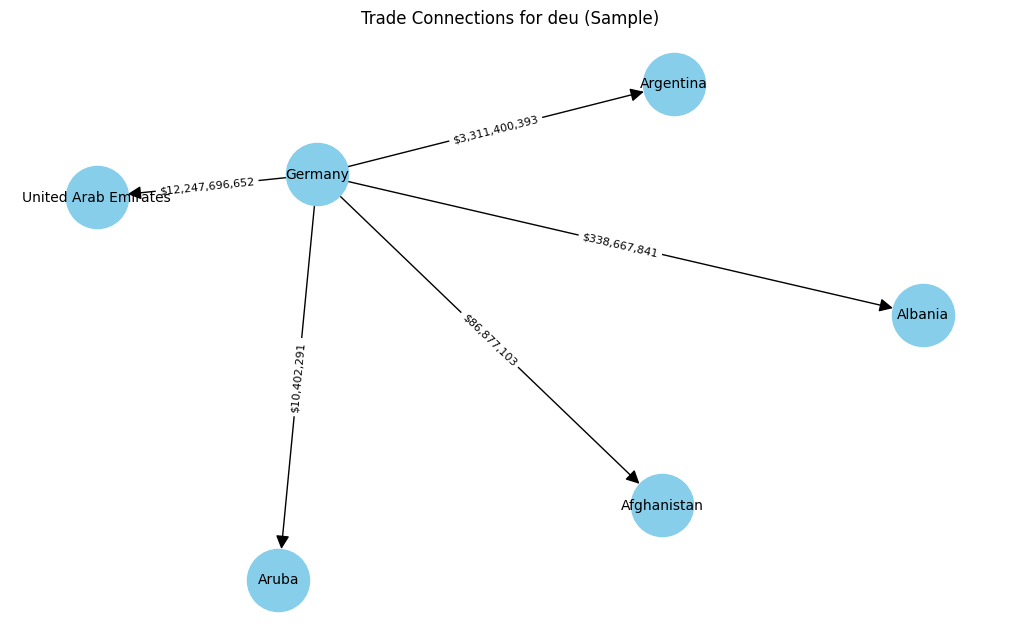

In [ ]:
if not has_llm_provider():
    print("Configuration Error: Please set API keys.")
else:
    q1 = "Who were the top 3 trade partners of Germany (deu) in 2014 by export value?"
    print(f"\nQuestion: {q1}")
    ans, cypher = answer_with_graph_rag(q1, conn)
    print(f"Answer: {ans}")

    print("\nVisualizing subgraph for Germany...")
    visualize_subgraph(conn, "deu")



## GRAPH-RAG is not fail proof:

In [ ]:
q2 = "Find countries in Africa that exported to both the USA (usa) and China (chn) in 2017."
print(f"\nQuestion: {q2}")
ans, cypher = answer_with_graph_rag(q2, conn)
print(f"Answer: {ans}")


Question: Find countries in Africa that exported to both the USA (usa) and China (chn) in 2017.
  [Cypher Generated]: MATCH (africanCountry:Country {continent: 'Africa'})
MATCH (usaCountry:Country {name: 'USA'})
MATCH (chinaCountry:Country {name: 'China'})
MATCH (africanCountry)-[:TRADE {year: 2017}]->(usaCountry)
MATCH (africanCountry)-[:TRADE {year: 2017}]->(chinaCountry)
RETURN africanCountry.name AS countryName LIMIT 50
Answer: Based on the graph results, there are no countries in Africa that exported to both the USA and China in 2017.


In [ ]:
q3 = "Which countries in Africa imported from USA (usa) in 2014."
print(f"\nQuestion: {q3}")
ans, cypher = answer_with_graph_rag(q3, conn)
print(f"Answer: {ans}")


Question: Which countries in Africa imported from USA (usa) in 2014.
  [Cypher Generated]: MATCH (usa:Country)-[t:TRADE]->(africaCountry:Country)
WHERE usa.name = 'USA'
  AND africaCountry.continent = 'Africa'
  AND t.year = 2014
RETURN africaCountry.name AS countryName
LIMIT 50
Answer: Based on the graph results, no countries in Africa imported from the USA in 2014.


#### Results of the above two queries seems suspect (*based on common sense*):
So I tried to write the Cypher queries myself, to compare results:

In [ ]:
### Query: Which countries in Africa imported from USA (usa) in 2014.

# The Cypher query adjusted for your database schema:
# - Node labels are 'Country'
# - The property for the country name is 'name'
# - The relationship is 'TRADE'
query = """
MATCH (usa:Country)-[t:TRADE]->(af:Country)
WHERE usa.name = 'United States'
  AND af.continent = 'Africa'
  AND t.year = 2014
  AND t.export_val > 0
RETURN af.name AS countryName ;
"""

# Execute the query and return the results as a Pandas DataFrame
# This will display as a formatted table in the notebook output
results_df = conn.execute(query).get_as_df()
print(results_df.head())
print(results_df.shape)

### USA exports to almost all African countries each year, this is something I knew in advance.


                countryName
0                    Angola
1                   Burundi
2                     Benin
3              Burkina Faso
4  Central African Republic
(49, 1)


In [ ]:
### QUERY: Find countries in Africa that exported to both the USA (usa) and China (chn) in 2017.

# The Cypher query adjusted for your database schema:
# - Node labels are 'Country'
# - The property for the country name is 'name'
# - The relationship is 'TRADE'
query = """
MATCH (usa:Country {name: 'United States'}), (chn:Country {name: 'China'})
MATCH (af:Country {continent: 'Africa'})-[t1:TRADE {year: 2017}]->(usa)
MATCH (af)-[t2:TRADE {year: 2017}]->(chn)
WHERE t1.export_val > 0 AND t2.export_val > 0
RETURN af.name AS countryName
"""

# Execute the query and return the results as a Pandas DataFrame
# This will display as a formatted table in the notebook output
results_df = conn.execute(query).get_as_df()
print(results_df.head())
print(results_df.shape)

### Almost every African country exports to USA as well as China each year, this is something I knew in advance.

  countryName
0       Benin
1    Zimbabwe
2    Cameroon
3     Algeria
4    Ethiopia
(48, 1)


## 7) Reflection & Teaching Notes

1. **Graph Patterns**: Notice how easily Cypher handles patterns like "exports to X AND exports to Y". In SQL, this would require multiple complex joins or subqueries.
2. **Schema context**: Why do we give the LLM the list of labels and properties? (Answer: So it knows which IDs to query, e.g., 'deu' vs 'Germany').
3. **Visualization**: How does the visual graph help you verify if the LLM's answer is correct?
4. **Pathfinding**: Ask the LLM: "Are there any indirect trade links (2-hops) between Country A and Country B that suggest a regional trade hub?"